# Notebook 5 

This notebook will extend notebook 4 now to work with a potential in 2 dimensions $V(x,y) = (4 - x^2)^2 + y^2$ calculating the time spent to go from a minimum to another one

# Section 1

First beginning by brute force simulation

Transition detected at index: 345, time: 3.45


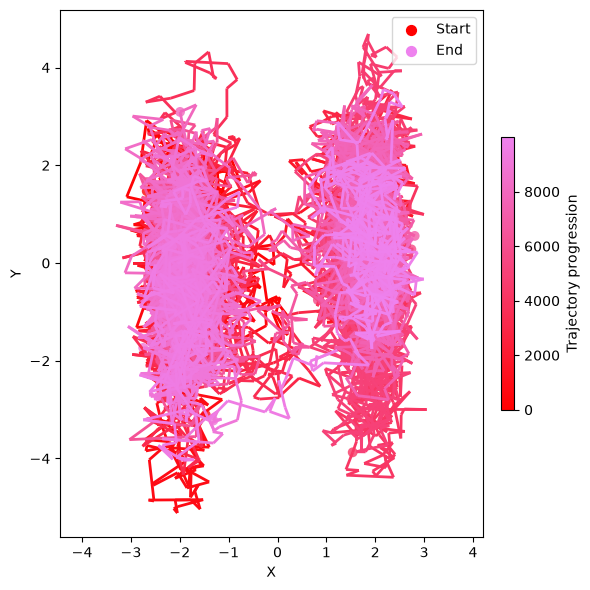

In [1]:
import numpy as np
from stage_escape.abp_abf.potential import Potential
from stage_escape.abp_abf.transition_detector import TransitionDetector
from stage_escape.brownian import BrownianMotion


dt = 0.01
potential = Potential(1, lambda x: (4 - x[0] ** 2) ** 2 + x[1] ** 2, lambda x: np.array([-4 * x[0] * (4 - x[0] ** 2), 2 * x[1]]))
# Parameter D set to 4 so that the transition occurs in a reasonable time frame
bm = BrownianMotion(num_steps=10000, delta_t=dt, dimension=2, D=4, initial_position=np.array([-1.5, 1.0]), b=lambda x: -potential.potential_prime_at(x))
bm.simulate()

td = TransitionDetector(bm.positions, lambda x: x[0], 0.0)
transition_index = td.detect_transition()
transition_time = transition_index * dt if transition_index is not None else None

print(f"Transition detected at index: {transition_index}, time: {transition_time}")
bm.plot_brownian_path(bm.positions, point_stride=100)

In [ ]:
import numpy as np
from stage_escape.abp_abf.potential import Potential
from stage_escape.abp_abf.transition_detector import TransitionDetector
from stage_escape.brownian import BrownianMotion
from stage_escape.statistics import Statistics
from joblib import Parallel, delayed


def run_one_simulation():
    dt = 0.01
    potential = Potential(1, lambda x: (4 - x[0] ** 2) ** 2 + x[1] ** 2, lambda x: np.array([-4 * x[0] * (4 - x[0] ** 2), 2 * x[1]]))


    bm = BrownianMotion(num_steps=10000, delta_t=dt, dimension=2, D=4, initial_position=np.array([-2.0, 0.0]), b=lambda x: -potential.potential_prime_at(x))
    bm.simulate()

    td = TransitionDetector(bm.positions, lambda x: x[0], 0.0)
    transition_index = td.detect_transition()
    transition_time = transition_index * dt if transition_index is not None else None
    return transition_time

Mean transition time: 9.616213
Standard deviation of transition times: 9.524428498793563


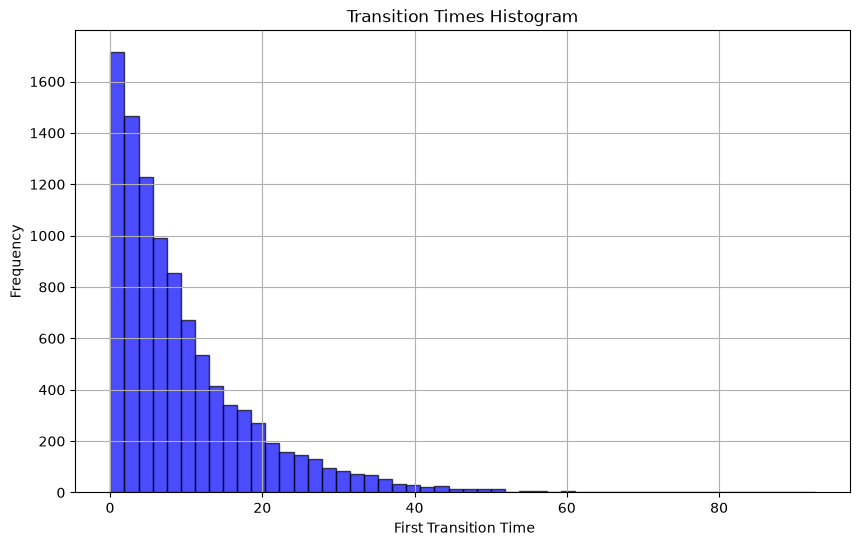

In [6]:
transition_times = []
exit_points = []

results = Parallel(n_jobs=-1)(
    delayed(run_one_simulation)()
    for _ in range(10000)
)

for transition_time in results:
    if transition_time is not None:
        transition_times.append(transition_time)

transition_times = np.array(transition_times)

mean_transition_time = np.mean(transition_times)

dev_transition_time = np.std(transition_times)

print(f"Mean transition time: {mean_transition_time}")
print(f"Standard deviation of transition times: {dev_transition_time}")
Statistics.plot_histogram(transition_times, bins=50, title="Transition Times Histogram", xlabel=" First Transition Time", ylabel="Frequency")

# Section 2

ABP applied to the problem

In [ ]:
import numpy as np
from stage_escape.abp_abf.potential import Potential
from stage_escape.abp_abf.transition_detector import TransitionDetector
from stage_escape.abp_abf.abp_metadynamics import ABPMetaDynamics
from stage_escape.statistics import Statistics
from joblib import Parallel, delayed


def run_one_simulation():
    dt = 0.01
    potential = Potential(1, lambda x: (4 - x[0] ** 2) ** 2 + x[1] ** 2, lambda x: np.array([-4 * x[0] * (4 - x[0] ** 2), 2 * x[1]]))


    abp = ABPMetaDynamics(num_steps=50, td=TransitionDetector(np.array([]), lambda x: x[0], 0.0), delta_t=dt, dimension=2, D=4, initial_position=np.array([-2.0, 0.0]), b=potential)
    transition_time, simulation_time = abp.simulate()

    return transition_time, transition_time /simulation_time

Mean transition time: 10.024032451989637
Standard deviation of transition times: 9.739574886949793
Mean acceleration factor: 90.86784077298701
Standard deviation of acceleration factors: 225.2023487975674


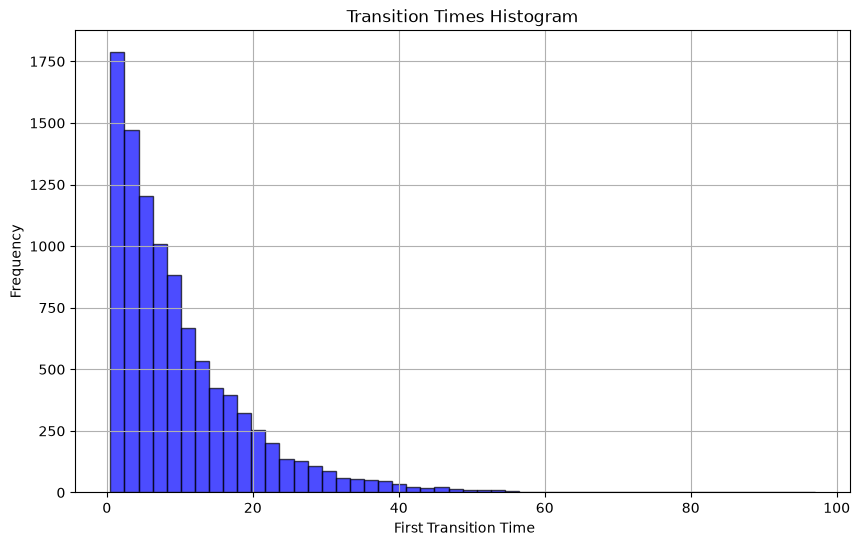

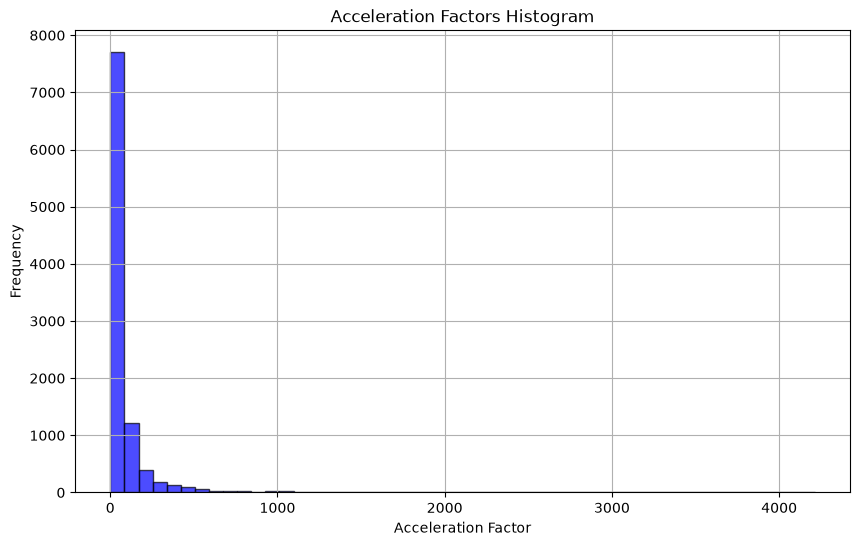

In [15]:
transition_times = []
acceleration_factors = []
exit_points = []

results = Parallel(n_jobs=-1)(
    delayed(run_one_simulation)()
    for _ in range(10000)
)

for transition_time, acc_factor in results:
    if transition_time is not None:
        transition_times.append(transition_time)
        acceleration_factors.append(acc_factor)

transition_times = np.array(transition_times)
acceleration_factors = np.array(acceleration_factors)

mean_transition_time = np.mean(transition_times)
mean_acceleration_factor = np.mean(acceleration_factors)

dev_transition_time = np.std(transition_times)
dev_acceleration_factor = np.std(acceleration_factors)

print(f"Mean transition time: {mean_transition_time}")
print(f"Standard deviation of transition times: {dev_transition_time}")

print(f"Mean acceleration factor: {mean_acceleration_factor}")
print(f"Standard deviation of acceleration factors: {dev_acceleration_factor}")

Statistics.plot_histogram(transition_times, bins=50, title="Transition Times Histogram", xlabel=" First Transition Time", ylabel="Frequency")
Statistics.plot_histogram(acceleration_factors, bins=50, title="Acceleration Factors Histogram", xlabel="Acceleration Factor", ylabel="Frequency")